# Day 1 — Routing and a Retry Loop

**Time:** 75–90 minutes  
**Build:** two bounded debuggers for the running knapsack bug.  
**Focus:** the model proposes; deterministic code decides the route and whether another loop is allowed.

Day 0 called the model once. Today we build two graphs:

1. A multi-state debugger that classifies the bug and routes to exactly one specialist branch.
2. A simple retry debugger that loops on one node until it is satisfied, within a hard limit.

Every debugger receives two inputs: the problem statement and the code.

Before running the notebook, complete the shared setup in the repository's main `README.md` and start MLflow.

## 1. Connect to the shared MLflow Gateway

In [1]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    base_url="http://127.0.0.1:5001/gateway/mlflow/v1",
    api_key="not-needed",
    model="workshop-gemini",
)

# Part 1 — Multi-State Debugger with Conditional Routing

A one-node loop sends work back to the same node. This graph instead chooses a specialist:

1. `triage` classifies the primary bug.
2. `syntax_debugger`, `runtime_debugger`, or `logic_debugger` investigates it.
3. `finalize` presents the result.

The graph contains five nodes, but one run visits only three of them. That is conditional routing. Every run receives both the problem statement and the code.

## 2. Define the prompts

The triage prompt decides where work should go. The specialist prompt describes what every branch must return.

In [4]:
TRIAGE_PROMPT = """
Classify the primary Python bug as syntax, runtime, or logic.

syntax: the code cannot be parsed
runtime: the code raises an error while running
logic: the code runs but returns the wrong result
"""

SPECIALIST_PROMPT = """
You are a {category} bug specialist.
Find the root cause, cite exact evidence, give the smallest fix,
and return the corrected code. Do not invent missing context.
"""

## 3. Define the schemas

`Literal` limits the category to the three routes that actually exist. This prevents the model from inventing a destination.

In [5]:
from typing import Literal
from pydantic import BaseModel

class Triage(BaseModel):
    category: Literal["syntax", "runtime", "logic"]
    summary: str

class Diagnosis(BaseModel):
    cause: str
    evidence: str
    fix: str
    corrected_code: str

triage_llm = llm.with_structured_output(Triage)
specialist_llm = llm.with_structured_output(Diagnosis)

## 4. Define the shared state and nodes

Every node receives the same state and returns only the fields it adds. `total=False` allows the state to grow as it moves through the graph.

In [6]:
from typing import TypedDict

class State(TypedDict, total=False):
    problem: str
    code: str
    triage: Triage
    diagnosis: Diagnosis
    answer: str

def triage(state: State):
    result = triage_llm.invoke([
        {"role": "system", "content": TRIAGE_PROMPT},
        {"role": "user", "content": f"Problem:\n{state['problem']}\n\nCode:\n{state['code']}"},
    ])
    return {"triage": result}

def diagnose(state: State, category: str):
    result = specialist_llm.invoke([
        {"role": "system", "content": SPECIALIST_PROMPT.format(category=category)},
        {"role": "user", "content": f"Problem:\n{state['problem']}\n\nCode:\n{state['code']}"},
    ])
    return {"diagnosis": result}

def syntax_debugger(state: State):
    return diagnose(state, "syntax")

def runtime_debugger(state: State):
    return diagnose(state, "runtime")

def logic_debugger(state: State):
    return diagnose(state, "logic")

def finalize(state: State):
    diagnosis = state["diagnosis"]
    answer = f"Cause: {diagnosis.cause}\nEvidence: {diagnosis.evidence}\nFix: {diagnosis.fix}\n\n{diagnosis.corrected_code}"
    return {"answer": answer}

## 5. Add conditional routing

The router reads structured state; it does not call the model. Its return value selects the next node. Before running, predict the route for code that parses and runs but returns a wrong answer.

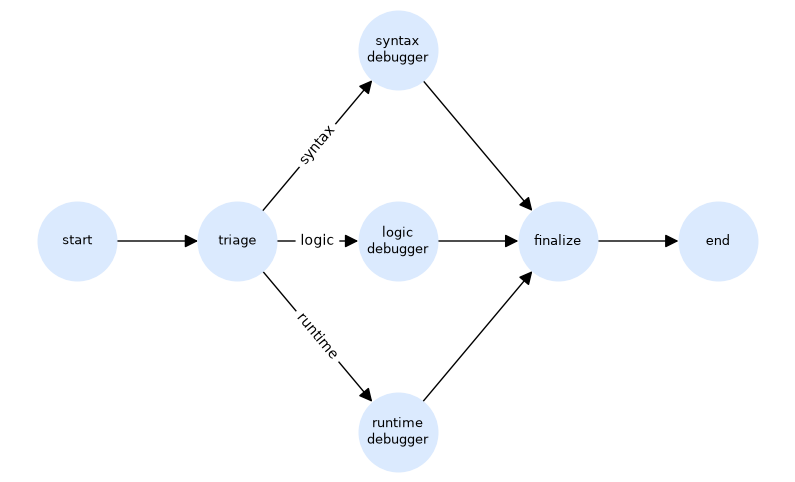

In [7]:
from langgraph.graph import END, START, StateGraph
import sys
sys.path.append("../..")
from graph_image import show_graph

def route_bug(state: State) -> Literal["syntax", "runtime", "logic"]:
    return state["triage"].category

builder = StateGraph(State)
builder.add_node("triage", triage)
builder.add_node("syntax_debugger", syntax_debugger)
builder.add_node("runtime_debugger", runtime_debugger)
builder.add_node("logic_debugger", logic_debugger)
builder.add_node("finalize", finalize)

builder.add_edge(START, "triage")
builder.add_conditional_edges("triage", route_bug, {
    "syntax": "syntax_debugger",
    "runtime": "runtime_debugger",
    "logic": "logic_debugger",
})
builder.add_edge("syntax_debugger", "finalize")
builder.add_edge("runtime_debugger", "finalize")
builder.add_edge("logic_debugger", "finalize")
builder.add_edge("finalize", END)

graph = builder.compile()
show_graph(graph)

## 6. Test the agent

Change the problem statement and code to exercise a different route.

In [8]:
problem_statement = "Choose items within the capacity and maximize value. Each item may be selected at most once."

buggy_code = """
n, capacity = map(int, input().split())
items = [tuple(map(int, input().split())) for _ in range(n)]
dp = [0] * (capacity + 1)
for weight, value in items:
    for current in range(weight, capacity + 1):
        dp[current] = max(dp[current], dp[current - weight] + value)
print(dp[capacity])
"""

result = graph.invoke({
    "problem": problem_statement,
    "code": buggy_code,
})

assert result["triage"].category == "logic"
assert result["answer"].strip()
print("Selected route:", result["triage"].category)
print(result["answer"])

ValidationError: 1 validation error for Triage
  Invalid JSON: expected value at line 1 column 1 [type=json_invalid, input_value="## Bug Classification: *...item 2 (weight 3+4=7) |", input_type=str]
    For further information visit https://errors.pydantic.dev/2.13/v/json_invalid

## Break, inspect, reflect

In a copy of `route_bug`, return `algorithm` instead of one of the three permitted values. Observe the routing failure, then restore the `Literal` contract.

**Exit question:** Which decisions should be model-generated, and which should remain deterministic routing code?

# Part 2 — A Simple Retrying Debugger

This agent has one job: understand the problem, inspect the code, review its previous attempts, and improve the diagnosis. It checks at least three times and stops after at most five attempts.

In [2]:
from typing import Literal, TypedDict
from pydantic import BaseModel
from langgraph.graph import END, START, StateGraph
import sys
sys.path.append("../..")
from graph_image import show_graph

SIMPLE_PROMPT = """
Debug the Python code. Review the previous attempts before answering.
Look for missed issues and return the best complete diagnosis and fix.
Set solved to true only when the corrected code addresses every issue found.
"""

class Attempt(BaseModel):
    diagnosis: str
    evidence: str
    corrected_code: str
    solved: bool

simple_debugger = llm.with_structured_output(Attempt)

## 7. Build the retry loop

The graph returns to `analyze` until the agent is satisfied and has checked three times. The limit guarantees that it cannot loop forever.

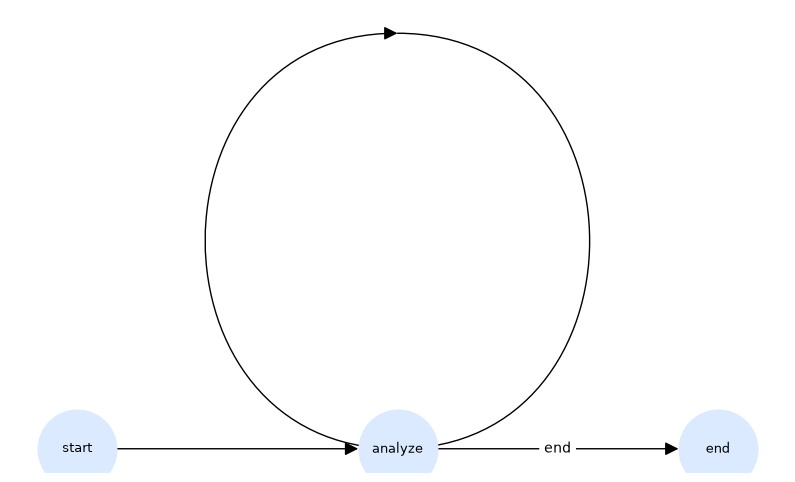

In [3]:
class RetryState(TypedDict):
    problem: str
    code: str
    attempt: int
    limit: int
    history: list[Attempt]

def simple_analyze(state: RetryState):
    previous = [attempt.model_dump() for attempt in state["history"]]
    result = simple_debugger.invoke([
        {"role": "system", "content": SIMPLE_PROMPT},
        {"role": "user", "content": f"Problem:\n{state['problem']}\n\nCode:\n{state['code']}\n\nPrevious attempts:\n{previous}"},
    ])
    return {
        "attempt": state["attempt"] + 1,
        "history": state["history"] + [result],
    }

def simple_route(state: RetryState) -> Literal["analyze", "end"]:
    if state["attempt"] >= state["limit"]:
        return "end"
    if state["attempt"] >= 3 and state["history"][-1].solved:
        return "end"
    return "analyze"

builder = StateGraph(RetryState)
builder.add_node("analyze", simple_analyze)
builder.add_edge(START, "analyze")
builder.add_conditional_edges("analyze", simple_route, {"analyze": "analyze", "end": END})
simple_graph = builder.compile()

show_graph(simple_graph)

## 8. Test the simple agent

In [4]:
problem_statement = "Choose items within the capacity and maximize value. Each item may be selected at most once."

buggy_code = """
n, capacity = map(int, input().split())
items = [tuple(map(int, input().split())) for _ in range(n)]
dp = [0] * (capacity + 1)
for weight, value in items:
    for current in range(weight, capacity + 1):
        dp[current] = max(dp[current], dp[current - weight] + value)
print(dp[capacity])
"""

result = simple_graph.invoke({
    "problem": problem_statement,
    "code": buggy_code,
    "attempt": 0,
    "limit": 5,
    "history": [],
})

assert 3 <= result["attempt"] <= 5
assert len(result["history"]) == result["attempt"]
print("Attempts:", result["attempt"])
print(result["history"][-1].model_dump_json(indent=2))

Attempts: 3
{
  "diagnosis": "The inner loop of the dynamic programming algorithm iterates through capacities in ascending order (range(weight, capacity + 1)). This allows an item to be selected multiple times in a single outer loop iteration, solving the unbounded knapsack problem instead of the 0/1 knapsack problem.",
  "evidence": "In the loop `for current in range(weight, capacity + 1):`, `dp[current - weight]` references a state that may have already been updated with the current item earlier in the same iteration. Reversing the inner loop to `range(capacity, weight - 1, -1)` ensures `dp[current - weight]` represents the state from previous items, guaranteeing each item is selected at most once.",
  "corrected_code": "n, capacity = map(int, input().split())\nitems = [tuple(map(int, input().split())) for _ in range(n)]\ndp = [0] * (capacity + 1)\nfor weight, value in items:\n    for current in range(capacity, weight - 1, -1):\n        dp[current] = max(dp[current], dp[current - wei

## Break, inspect, reflect

Temporarily weaken `simple_route` in a copy so it can stop only when `history[-1].solved` is true, removing the `state["attempt"] >= state["limit"]` guard. Explain why trusting only the model's `solved` flag is unsafe, then restore the limit before running.

**Exit question:** The model keeps setting `solved` to false. Which component has final authority to stop the graph?